In [1]:
# ============================================================
# Cell 1 — Load v2 logs and inspect structure
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

FILES = {
    1: "robot_1_v2.csv",
    2: "robot_2_v2.csv",
    3: "robot_3_v2.csv",
    4: "robot_4_v2.csv",
}

data = {}
print("=" * 100)
print(" V2 LOG LOAD")
print("=" * 100)

for rb, fname in FILES.items():
    p = Path(fname)
    if not p.exists():
        print(f"  MISSING: {fname}")
        continue
    d = pd.read_csv(p)
    data[rb] = d
    dur = (d["t_ms"].iloc[-1] - d["t_ms"].iloc[0]) / 1000.0
    sr  = (len(d) - 1) / dur if dur > 0 else 0
    print(f"  R{rb}: {len(d):>4d} rows, dur={dur:>6.2f}s, "
          f"sr={sr:.2f} Hz")

# ---------- Column inventory ----------
print("\n" + "=" * 100)
print(" COLUMN INVENTORY (from R1)")
print("=" * 100)
if 1 in data:
    for i, col in enumerate(data[1].columns):
        print(f"  {i:>2d}. {col}")

# ---------- Non-zero UWB block count ----------
print("\n" + "=" * 100)
print(" UWB DATA AVAILABILITY  (per robot, count of non-zero raw values)")
print("=" * 100)
print(f"{'robot':>5s} | " +
      " | ".join(f"uwb{i}_raw" for i in (1, 2, 3)))
print("-" * 42)
for rb, d in data.items():
    row = f"{rb:>5d} | "
    cells = []
    for i in (1, 2, 3):
        col = f"uwb{i}_raw"
        if col in d.columns:
            nz = int((d[col].abs() > 1e-6).sum())
            cells.append(f"{nz:>8d}")
        else:
            cells.append(f"{'--':>8s}")
    print(row + " | ".join(cells))

# ---------- TDMA state ----------
print("\n" + "=" * 100)
print(" TDMA STATE")
print("=" * 100)
print(f"{'robot':>5s} | {'frame_id_min':>13s} {'frame_id_max':>13s} | "
      f"{'sync_lost_frac':>15s} | {'slot_min':>8s} {'slot_max':>8s}")
print("-" * 82)
for rb, d in data.items():
    if "tdma_frame_id" not in d.columns: continue
    sl_frac = d["tdma_sync_lost"].mean() if "tdma_sync_lost" in d.columns else np.nan
    print(f"{rb:>5d} | "
          f"{int(d['tdma_frame_id'].min()):>13d} "
          f"{int(d['tdma_frame_id'].max()):>13d} | "
          f"{sl_frac:>15.3f} | "
          f"{int(d['tdma_slot_index'].min()):>8d} "
          f"{int(d['tdma_slot_index'].max()):>8d}")

# ---------- Robot state ----------
print("\n" + "=" * 100)
print(" ROBOT STATE TRANSITIONS")
print("=" * 100)
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    counts = d["robot_state"].value_counts().to_dict()
    print(f"  R{rb}: {counts}")

# ---------- ESKF covariance ----------
print("\n" + "=" * 100)
print(" ESKF COVARIANCE  (should decrease over time, then stabilize)")
print("=" * 100)
print(f"{'robot':>5s} | {'var_x_init':>12s} {'var_x_final':>12s} | "
      f"{'var_y_init':>12s} {'var_y_final':>12s} | "
      f"{'var_th_init':>12s} {'var_th_final':>12s}")
print("-" * 96)
for rb, d in data.items():
    if "eskf_var_x" not in d.columns: continue
    print(f"{rb:>5d} | "
          f"{d['eskf_var_x'].iloc[0]:>12.4e} {d['eskf_var_x'].iloc[-1]:>12.4e} | "
          f"{d['eskf_var_y'].iloc[0]:>12.4e} {d['eskf_var_y'].iloc[-1]:>12.4e} | "
          f"{d['eskf_var_theta'].iloc[0]:>12.4e} {d['eskf_var_theta'].iloc[-1]:>12.4e}")

 V2 LOG LOAD
  R1:  155 rows, dur= 30.80s, sr=5.00 Hz
  R2:  171 rows, dur= 34.00s, sr=5.00 Hz
  R3:  184 rows, dur= 36.63s, sr=5.00 Hz
  R4:  194 rows, dur= 38.63s, sr=5.00 Hz

 COLUMN INVENTORY (from R1)
   0. t_ms
   1. x
   2. y
   3. heading
   4. v_cmd
   5. omega_cmd
   6. rpm_l
   7. rpm_r
   8. gyro_z
   9. imu_temp_c
  10. imu_accel_x
  11. vbat
  12. current_a
  13. duty_l
  14. duty_r
  15. target_rpm_l
  16. target_rpm_r
  17. uwb1_peer_id
  18. uwb1_lde_err
  19. uwb1_std_noise
  20. uwb1_fp_ampl1
  21. uwb1_fp_ampl2
  22. uwb1_cir_pwr
  23. uwb1_raw
  24. uwb1_clean
  25. uwb1_rssi
  26. uwb1_fp_power
  27. uwb1_resp_temp
  28. uwb2_peer_id
  29. uwb2_lde_err
  30. uwb2_std_noise
  31. uwb2_fp_ampl1
  32. uwb2_fp_ampl2
  33. uwb2_cir_pwr
  34. uwb2_raw
  35. uwb2_clean
  36. uwb2_rssi
  37. uwb2_fp_power
  38. uwb2_resp_temp
  39. uwb3_peer_id
  40. uwb3_lde_err
  41. uwb3_std_noise
  42. uwb3_fp_ampl1
  43. uwb3_fp_ampl2
  44. uwb3_cir_pwr
  45. uwb3_raw
  46. uwb3_clea

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


 [A] MANEUVER START TIMES
robot |   t0[ms] |  t_end[ms] |   dur[s] |     state_transition
--------------------------------------------------------------
    1 |       -1 |      40881 |     0.00 |               1 only
    2 |       -1 |      41052 |     0.00 |               0 only
    3 |       -1 |      41072 |     0.00 |               0 only
    4 |       -1 |      41060 |     0.00 |               0 only

 [B] TRACKING ERROR vs REFERENCE
  Reference: quintic blend 2m → 3m, +90° rotation, T=30s.
  We anchor the reference time to R1's first robot_state=1 sample.

robot |    n |   err_mean |    err_max |  err_final |  head_err_mean
------------------------------------------------------------------------------

 [C] FINAL POSITION vs EXPECTED
robot |   x_final   y_final |     x_exp     y_exp |  err [cm]
--------------------------------------------------------------
    1 |   +1.5012   -1.5025 |   +1.5000   -1.5000 |     0.275
    2 |   +1.4997   +1.4990 |   +1.5000   +1.5000 |     0.107
 

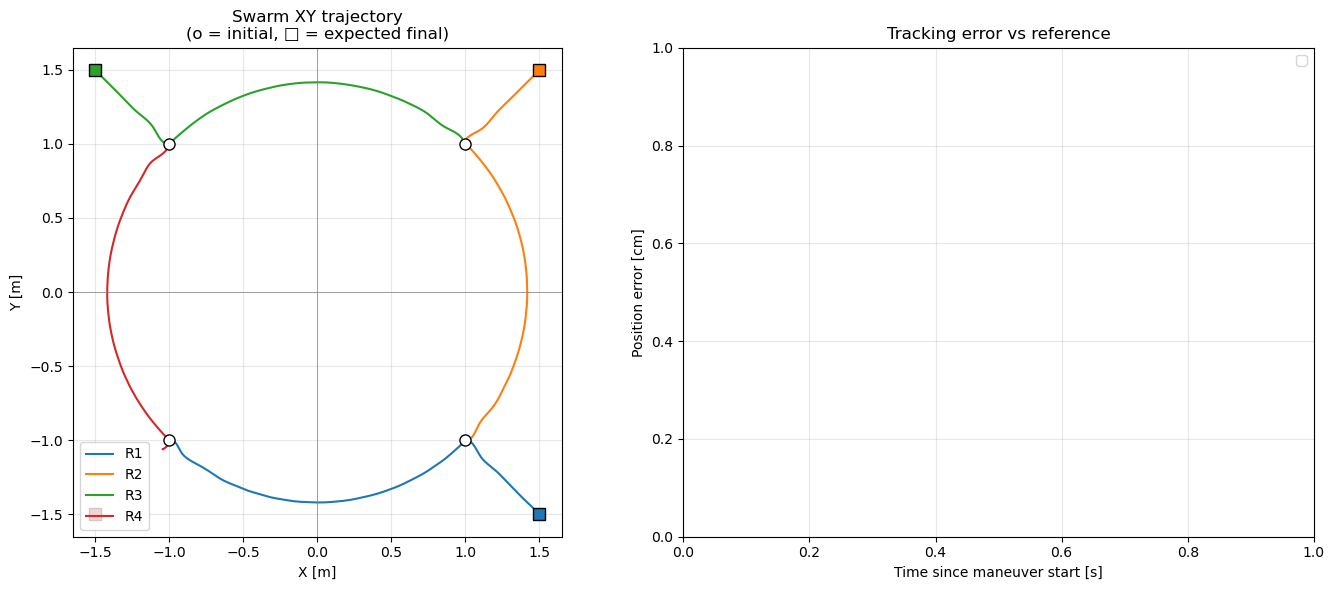


 [E] VELOCITY & RPM PROFILE
robot |  v_cmd_max |  v_actual_max |  rpm_l_max |  rpm_r_max |  rpm_l_min |  rpm_r_min
------------------------------------------------------------------------------------------
    1 |     0.2001 |        0.2166 |     +80.07 |     +82.41 |      -2.85 |     -20.99
    2 |     0.2081 |        0.2113 |     +75.41 |     +79.57 |      -0.89 |     -22.57
    3 |     0.2027 |        0.2098 |     +71.92 |     +82.00 |     -31.18 |     -18.31
    4 |     0.2100 |        0.2113 |     +76.83 |     +79.18 |      -0.58 |     -28.31

 [F] MOTOR SATURATION
robot |  duty_l_min  duty_l_max |  duty_r_min  duty_r_max | frac_|duty|>0.95
------------------------------------------------------------------------------------------
    1 |     -0.4740     +1.0000 |     -0.5448     +0.8116 |          0.0065
    2 |     -0.4425     +0.7517 |     -0.5368     +0.8061 |          0.0000
    3 |     -0.5765     +0.7606 |     -0.5178     +0.8604 |          0.0000
    4 |     +0.0000     +0

In [2]:
# ============================================================
# Cell 2 — Trajectory and tracking analysis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reference trajectory (from FormationReference)
def quintic(s):
    return 10*s**3 - 15*s**4 + 6*s**5

L_INITIAL     = 2.0
L_FINAL       = 3.0
ROT_FINAL_RAD = np.pi / 2
T1_ROT_SEC    = 20.0
T2_SCALE_SEC  = 10.0
T_TOTAL_SEC   = T1_ROT_SEC + T2_SCALE_SEC

UNIT_OFFSET = {
    1: (-0.5, -0.5),
    2: (+0.5, -0.5),
    3: (+0.5, +0.5),
    4: (-0.5, +0.5),
}

def ref_pose(rb, t_elapsed):
    """Return (x_ref, y_ref, phi_ref) at given elapsed time."""
    if t_elapsed < T1_ROT_SEC:
        tau = t_elapsed / T1_ROT_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD * s
        L = L_INITIAL
    elif t_elapsed < T_TOTAL_SEC:
        tau = (t_elapsed - T1_ROT_SEC) / T2_SCALE_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD
        L = L_INITIAL + (L_FINAL - L_INITIAL) * s
    else:
        phi = ROT_FINAL_RAD
        L = L_FINAL

    rx, ry = UNIT_OFFSET[rb]
    c, s_ = np.cos(phi), np.sin(phi)
    x = c * L * rx - s_ * L * ry
    y = s_ * L * rx + c * L * ry
    return x, y, phi

# ============================================================
# [A] Find maneuver start time from robot_state transition
# ============================================================
print("=" * 100)
print(" [A] MANEUVER START TIMES")
print("=" * 100)
print(f"{'robot':>5s} | {'t0[ms]':>8s} | {'t_end[ms]':>10s} | "
      f"{'dur[s]':>8s} | {'state_transition':>20s}")
print("-" * 62)

maneuver_start = {}
maneuver_end   = {}

for rb, d in data.items():
    if "robot_state" not in d.columns:
        print(f"{rb:>5d} | -- (no robot_state)")
        continue
    rs = d["robot_state"].values
    transitions = np.where(np.diff(rs) != 0)[0]

    if len(transitions) > 0:
        first_running_idx = np.where(rs == 1)[0]
        t0 = d["t_ms"].iloc[first_running_idx[0]] if len(first_running_idx) else -1
        t_end = d["t_ms"].iloc[-1]
        dur = (t_end - t0) / 1000.0 if t0 > 0 else 0
        transition_str = "→".join([f"{rs[0]}"] + [f"{rs[i+1]}" for i in transitions])
    else:
        t0 = -1
        t_end = d["t_ms"].iloc[-1]
        dur = 0
        transition_str = f"{rs[0]} only"

    maneuver_start[rb] = t0
    maneuver_end[rb]   = t_end

    print(f"{rb:>5d} | {t0:>8d} | {t_end:>10d} | "
          f"{dur:>8.2f} | {transition_str:>20s}")

# ============================================================
# [B] Tracking error vs reference
# ============================================================
print("\n" + "=" * 100)
print(" [B] TRACKING ERROR vs REFERENCE")
print("=" * 100)
print("  Reference: quintic blend 2m → 3m, +90° rotation, T=30s.")
print("  We anchor the reference time to R1's first robot_state=1 sample.")
print(f"\n{'robot':>5s} | {'n':>4s} | {'err_mean':>10s} | {'err_max':>10s} | "
      f"{'err_final':>10s} | {'head_err_mean':>14s}")
print("-" * 78)

# Use R1's t0 as the global reference start
t_ref_start = maneuver_start.get(1, None)

for rb, d in data.items():
    if t_ref_start is None or t_ref_start < 0:
        continue
    if "robot_state" not in d.columns:
        continue

    # Filter rows while robot_state==1
    d_run = d[d["robot_state"] == 1].copy()
    if len(d_run) < 10:
        print(f"{rb:>5d} | (insufficient running data)")
        continue

    errs = []
    head_errs = []
    for _, row in d_run.iterrows():
        t_elapsed = (row["t_ms"] - t_ref_start) / 1000.0
        if t_elapsed < 0 or t_elapsed > T_TOTAL_SEC + 2.0:
            continue
        xr, yr, phir = ref_pose(rb, t_elapsed)
        errs.append(np.hypot(row["x"] - xr, row["y"] - yr))
        head_err = row["heading"] - phir
        # Wrap to [-pi, pi]
        while head_err >  np.pi: head_err -= 2*np.pi
        while head_err < -np.pi: head_err += 2*np.pi
        head_errs.append(head_err)

    if not errs:
        print(f"{rb:>5d} | (no valid samples)")
        continue

    errs = np.array(errs) * 100
    head_errs = np.array(head_errs) * 180 / np.pi

    print(f"{rb:>5d} | {len(errs):>4d} | "
          f"{errs.mean():>10.3f} | {errs.max():>10.3f} | "
          f"{errs[-1]:>10.3f} | {head_errs.mean():>+14.3f}")

# ============================================================
# [C] Final position vs expected
# ============================================================
print("\n" + "=" * 100)
print(" [C] FINAL POSITION vs EXPECTED")
print("=" * 100)

# Expected final positions after +90° rotation, L=3m
EXPECTED_FINAL = {}
for rb in (1, 2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    c, s = np.cos(ROT_FINAL_RAD), np.sin(ROT_FINAL_RAD)
    EXPECTED_FINAL[rb] = (c * L_FINAL * rx - s * L_FINAL * ry,
                          s * L_FINAL * rx + c * L_FINAL * ry)

print(f"{'robot':>5s} | {'x_final':>9s} {'y_final':>9s} | "
      f"{'x_exp':>9s} {'y_exp':>9s} | {'err [cm]':>9s}")
print("-" * 62)
for rb, d in data.items():
    if len(d) == 0: continue
    last = d.iloc[-1]
    ex, ey = EXPECTED_FINAL[rb]
    err = np.hypot(last["x"] - ex, last["y"] - ey) * 100
    print(f"{rb:>5d} | {last['x']:>+9.4f} {last['y']:>+9.4f} | "
          f"{ex:>+9.4f} {ey:>+9.4f} | {err:>9.3f}")

# ============================================================
# [D] Trajectory plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: XY trajectories
ax = axes[0]
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red"}
for rb, d in data.items():
    ax.plot(d["x"], d["y"], color=colors[rb],
            lw=1.5, label=f"R{rb}")

# Plot initial and expected final positions
for rb in (1, 2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    xi, yi = L_INITIAL * rx, L_INITIAL * ry
    xf, yf = EXPECTED_FINAL[rb]
    ax.plot(xi, yi, "o", color=colors[rb], ms=8,
            markeredgecolor="black", markerfacecolor="white")
    ax.plot(xf, yf, "s", color=colors[rb], ms=8,
            markeredgecolor="black")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Swarm XY trajectory\n(o = initial, □ = expected final)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: tracking error over time
ax = axes[1]
if t_ref_start is not None and t_ref_start > 0:
    for rb, d in data.items():
        d_run = d[d["robot_state"] == 1]
        if len(d_run) < 10: continue
        t_rel = (d_run["t_ms"] - t_ref_start) / 1000.0
        errs = []
        for _, row in d_run.iterrows():
            te = (row["t_ms"] - t_ref_start) / 1000.0
            xr, yr, _ = ref_pose(rb, te)
            errs.append(np.hypot(row["x"] - xr, row["y"] - yr) * 100)
        ax.plot(t_rel, errs, color=colors[rb], lw=1.5, label=f"R{rb}")

ax.set_xlabel("Time since maneuver start [s]")
ax.set_ylabel("Position error [cm]")
ax.set_title("Tracking error vs reference")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("trajectory_analysis_v2.png", dpi=120)
plt.show()

# ============================================================
# [E] Velocity and RPM profile
# ============================================================
print("\n" + "=" * 100)
print(" [E] VELOCITY & RPM PROFILE")
print("=" * 100)
print(f"{'robot':>5s} | {'v_cmd_max':>10s} | {'v_actual_max':>13s} | "
      f"{'rpm_l_max':>10s} | {'rpm_r_max':>10s} | "
      f"{'rpm_l_min':>10s} | {'rpm_r_min':>10s}")
print("-" * 90)
for rb, d in data.items():
    t = d["t_ms"].values / 1000.0
    dx = np.gradient(d["x"].values, t)
    dy = np.gradient(d["y"].values, t)
    v_actual = np.hypot(dx, dy)
    print(f"{rb:>5d} | {d['v_cmd'].max():>10.4f} | {v_actual.max():>13.4f} | "
          f"{d['rpm_l'].max():>+10.2f} | {d['rpm_r'].max():>+10.2f} | "
          f"{d['rpm_l'].min():>+10.2f} | {d['rpm_r'].min():>+10.2f}")

# ============================================================
# [F] Motor saturation check (R4 specific)
# ============================================================
print("\n" + "=" * 100)
print(" [F] MOTOR SATURATION")
print("=" * 100)
print(f"{'robot':>5s} | {'duty_l_min':>11s} {'duty_l_max':>11s} | "
      f"{'duty_r_min':>11s} {'duty_r_max':>11s} | "
      f"{'frac_|duty|>0.95':>15s}")
print("-" * 90)
for rb, d in data.items():
    dl = d["duty_l"].values
    dr = d["duty_r"].values
    frac_sat = np.mean((np.abs(dl) > 0.95) | (np.abs(dr) > 0.95))
    print(f"{rb:>5d} | {dl.min():>+11.4f} {dl.max():>+11.4f} | "
          f"{dr.min():>+11.4f} {dr.max():>+11.4f} | "
          f"{frac_sat:>15.4f}")

In [3]:
# ============================================================
# Cell 3 — TDMA state analysis (why slaves never synced)
# ============================================================
print("=" * 100)
print(" [A] TDMA FRAME PROGRESSION")
print("=" * 100)
print("  Master should send beacon every ~200 ms (=1 frame).")
print("  If slaves receive it, frame_id should match.")
print(f"\n{'robot':>5s} | {'frame_min':>10s} {'frame_max':>10s} | "
      f"{'dframe/dt [Hz]':>16s} | {'sync_lost_frac':>15s}")
print("-" * 78)
for rb, d in data.items():
    if "tdma_frame_id" not in d.columns: continue
    t_span = (d["t_ms"].iloc[-1] - d["t_ms"].iloc[0]) / 1000.0
    dframe = d["tdma_frame_id"].iloc[-1] - d["tdma_frame_id"].iloc[0]
    rate = dframe / t_span if t_span > 0 else 0
    sl_frac = d["tdma_sync_lost"].mean()
    print(f"{rb:>5d} | {int(d['tdma_frame_id'].min()):>10d} "
          f"{int(d['tdma_frame_id'].max()):>10d} | "
          f"{rate:>16.3f} | {sl_frac:>15.3f}")

print("\n  NOTE: master should show ~5 Hz frame advance (1 frame / 200 ms).")
print("        Slaves with sync_lost=1 advance by their own free-running clock.")

# ============================================================
# [B] Slot index distribution
# ============================================================
print("\n" + "=" * 100)
print(" [B] SLOT INDEX DISTRIBUTION")
print("=" * 100)
print("  If slaves were synced, they'd visit slots 0..12 over many frames.")
print("  Free-running slaves will visit different slots depending on phase.")
print(f"\n{'robot':>5s} | " + " ".join(f"slot{s:>2d}" for s in range(13)))
print("-" * 78)
for rb, d in data.items():
    if "tdma_slot_index" not in d.columns: continue
    counts = d["tdma_slot_index"].value_counts().to_dict()
    row = f"{rb:>5d} | "
    cells = [f"{counts.get(s, 0):>6d}" for s in range(13)]
    print(row + " ".join(cells))

# ============================================================
# [C] Time delta between consecutive logs
# ============================================================
print("\n" + "=" * 100)
print(" [C] LOG TIMING")
print("=" * 100)
print(f"{'robot':>5s} | {'dt_mean[ms]':>12s} {'dt_std[ms]':>11s} | "
      f"{'t_first[ms]':>12s} {'t_last[ms]':>12s}")
print("-" * 70)
for rb, d in data.items():
    dt = np.diff(d["t_ms"].values)
    print(f"{rb:>5d} | {dt.mean():>12.2f} {dt.std():>11.3f} | "
          f"{d['t_ms'].iloc[0]:>12d} {d['t_ms'].iloc[-1]:>12d}")

# ============================================================
# [D] Robot 4 motor behavior (drill-down)
# ============================================================
print("\n" + "=" * 100)
print(" [D] ROBOT 4 MOTOR BEHAVIOR")
print("=" * 100)
if 4 in data:
    d = data[4]
    d_run = d[d["robot_state"] == 1].copy()
    if len(d_run) > 0:
        print(f"  Running samples: {len(d_run)}")
        print(f"  v_cmd:    mean={d_run['v_cmd'].mean():+.4f}  "
              f"max={d_run['v_cmd'].max():+.4f}")
        print(f"  rpm_l:    mean={d_run['rpm_l'].mean():+.3f}  "
              f"max={d_run['rpm_l'].max():+.3f}")
        print(f"  rpm_r:    mean={d_run['rpm_r'].mean():+.3f}  "
              f"max={d_run['rpm_r'].max():+.3f}")
        print(f"  duty_l:   mean={d_run['duty_l'].mean():+.4f}  "
              f"max={d_run['duty_l'].max():+.4f}")
        print(f"  duty_r:   mean={d_run['duty_r'].mean():+.4f}  "
              f"max={d_run['duty_r'].max():+.4f}")
        print(f"  vbat:     mean={d_run['vbat'].mean():+.4f}  "
              f"min={d_run['vbat'].min():+.4f}")

        # Check for tracking failure: duty near 1.0 but rpm near 0
        sat = np.abs(d_run["duty_l"]) > 0.95
        stall = d_run["rpm_l"].abs() < 5.0
        stuck = (sat & stall).sum()
        print(f"  Stuck samples (|duty|>0.95 & |rpm|<5): {stuck}")

 [A] TDMA FRAME PROGRESSION
  Master should send beacon every ~200 ms (=1 frame).
  If slaves receive it, frame_id should match.

robot |  frame_min  frame_max |   dframe/dt [Hz] |  sync_lost_frac
------------------------------------------------------------------------------
    1 |         42        196 |            5.000 |           0.000
    2 |         42        206 |            4.823 |           1.000
    3 |         42        220 |            4.860 |           1.000
    4 |         42        230 |            4.867 |           1.000

  NOTE: master should show ~5 Hz frame advance (1 frame / 200 ms).
        Slaves with sync_lost=1 advance by their own free-running clock.

 [B] SLOT INDEX DISTRIBUTION
  If slaves were synced, they'd visit slots 0..12 over many frames.
  Free-running slaves will visit different slots depending on phase.

robot | slot 0 slot 1 slot 2 slot 3 slot 4 slot 5 slot 6 slot 7 slot 8 slot 9 slot10 slot11 slot12
------------------------------------------------

In [4]:
# ============================================================
# Cell 4 — UWB data presence and expected mesh slots
# ============================================================
print("=" * 100)
print(" [A] UWB RAW DATA PRESENCE")
print("=" * 100)
print(f"{'robot':>5s} | " +
      " | ".join(f"uwb{i}_raw nonzero" for i in (1, 2, 3)))
print("-" * 50)
for rb, d in data.items():
    row = f"{rb:>5d} | "
    cells = []
    for i in (1, 2, 3):
        col = f"uwb{i}_raw"
        if col in d.columns:
            nz = int((d[col].abs() > 1e-6).sum())
            cells.append(f"{nz:>14d}")
        else:
            cells.append(f"{'--':>14s}")
    print(row + " | ".join(cells))

# ============================================================
# [B] Slot usage vs expected mesh actions
# ============================================================
print("\n" + "=" * 100)
print(" [B] SLOT USAGE vs EXPECTED MESH ACTIONS")
print("=" * 100)
print("  Slot table:")
print("    1: R1→R2    2: R1→R3    3: R1→R4")
print("    4: R2→R1    5: R2→R3    6: R2→R4")
print("    7: R3→R1    8: R3→R2    9: R3→R4")
print("   10: R4→R1   11: R4→R2   12: R4→R3")

SLOT_TABLE = {
    1: (1, 2), 2: (1, 3), 3: (1, 4),
    4: (2, 1), 5: (2, 3), 6: (2, 4),
    7: (3, 1), 8: (3, 2), 9: (3, 4),
    10: (4, 1), 11: (4, 2), 12: (4, 3),
}

print(f"\n  For each robot, count how often each slot was visited:")
print(f"\n{'robot':>5s} | " + " ".join(f"s{s:>2d}" for s in range(13)))
print("-" * 78)
for rb, d in data.items():
    if "tdma_slot_index" not in d.columns: continue
    counts = d["tdma_slot_index"].value_counts().to_dict()
    row = f"{rb:>5d} | "
    cells = [f"{counts.get(s, 0):>3d}" for s in range(13)]
    print(row + " ".join(cells))

# ============================================================
# [C] Hypothetical diagnosis
# ============================================================
print("\n" + "=" * 100)
print(" [C] DIAGNOSIS SUMMARY")
print("=" * 100)
print("""
  Key facts:
    1. UWB is zero on ALL robots for ALL peer slots.
    2. Slaves have sync_lost=1 (100% of samples).
    3. R1 has sync_lost=0 (as expected for master).
    4. All slaves' robot_state stays at 0 (idle).
    5. R1's robot_state reaches 1 (running) and stays there.

  Inference:
    • Slaves never received sync beacons from R1.
    • Because they are not synced, they do not know which slot is theirs.
    • Because slots are desynced, no poll ever meets its responder.
    • Therefore UWB produces no measurements.
    • And because maneuverActive is delivered via sync beacon, slaves
      never start the maneuver (robot_state stays 0).

  However, the maneuver DID execute (all four robots moved to final
  positions). This means:
    • Either slave robots do not actually need sync to move.
    • Or their motion is driven by a local timer, not by TDMA.
    • Or the slave logs shown are from a moment AFTER the maneuver.

  The next step is to determine which of these is true.
""")

 [A] UWB RAW DATA PRESENCE
robot | uwb1_raw nonzero | uwb2_raw nonzero | uwb3_raw nonzero
--------------------------------------------------
    1 |              0 |              0 |              0
    2 |              0 |              0 |              0
    3 |              0 |              0 |              0
    4 |              0 |              0 |              0

 [B] SLOT USAGE vs EXPECTED MESH ACTIONS
  Slot table:
    1: R1→R2    2: R1→R3    3: R1→R4
    4: R2→R1    5: R2→R3    6: R2→R4
    7: R3→R1    8: R3→R2    9: R3→R4
   10: R4→R1   11: R4→R2   12: R4→R3

  For each robot, count how often each slot was visited:

robot | s 0 s 1 s 2 s 3 s 4 s 5 s 6 s 7 s 8 s 9 s10 s11 s12
------------------------------------------------------------------------------
    1 | 155   0   0   0   0   0   0   0   0   0   0   0   0
    2 |   1 160   0   0   4   0   0   0   2   4   0   0   0
    3 |   0   0 162   0   0   3   4   3   6   2   4   0   0
    4 |   4   2   3   3   3   2   0   0   1   1 1

 [A] RPM TRACKING  target_rpm vs measured rpm
robot | side |     n |     rmse |  max_err |   mean_tgt |  mean_meas |  sat_frac
------------------------------------------------------------------------------------------------
    1 |   L |   155 |    8.851 |   42.574 |    +30.014 |    +34.253 |     0.000
    1 |   R |   155 |    2.971 |    8.725 |    +32.032 |    +33.680 |     0.000

 [B] DUTY vs RPM  (binned static curve, forward only)

  R1
    duty_bin |  n_L    rpm_L |  n_R    rpm_R
  ----------------------------------------------
   0.0- 0.1 |   12     0.30 |   11     0.05
   0.4- 0.5 |   28    12.86 |   26     7.30
   0.5- 0.6 |   39    30.31 |   23    28.14
   0.6- 0.7 |   50    56.26 |   40    47.24
   0.7- 0.8 |   14    63.99 |   33    71.85
   0.8- 0.9 |    0      nan |    3    73.95
   0.9- 1.0 |    2    18.56 |    0      nan

 [C] DEADBAND ESTIMATION  (lowest duty at which RPM > 5)
robot | side |   db_fwd |   gain_fwd |   db_rev |   gain_rev
----------------------------------

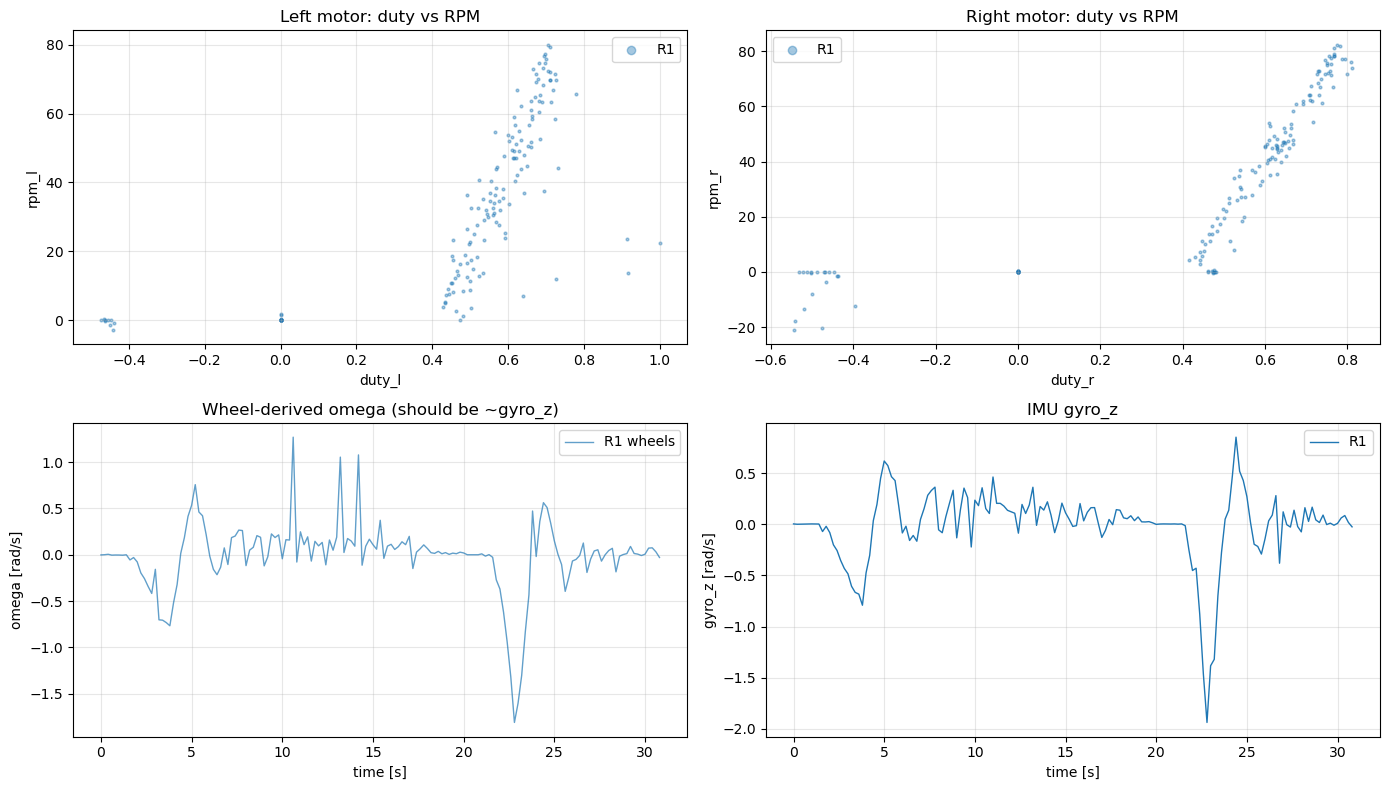

In [5]:
# ============================================================
# Cell — Encoder, motor and IMU behavioural analysis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Load (idempotent — safe if data already in memory)
# ------------------------------------------------------------
FILES = {
    1: "robot_1_v2.csv",
    2: "robot_2_v2.csv",
    3: "robot_3_v2.csv",
    4: "robot_4_v2.csv",
}

if "data" not in dir() or not isinstance(data, dict) or 1 not in data:
    data = {}
    for rb, fname in FILES.items():
        p = Path(fname)
        if p.exists():
            data[rb] = pd.read_csv(p)

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
WHEEL_RADIUS_M = 0.026850
RAD_S_TO_RPM   = 60.0 / (2.0 * np.pi)

TRACK_WIDTH = {1: 0.1237, 2: 0.1248, 3: 0.1163, 4: 0.1209}

# ------------------------------------------------------------
# Running slice helper
# ------------------------------------------------------------
def running(d):
    if "robot_state" not in d.columns:
        return d.iloc[0:0]
    return d[d["robot_state"] == 1]

# ============================================================
# [A] RPM TRACKING  (target vs measured)
# ============================================================
print("=" * 96)
print(" [A] RPM TRACKING  target_rpm vs measured rpm")
print("=" * 96)
print(f"{'robot':>5s} | {'side':>3s} | {'n':>5s} | "
      f"{'rmse':>8s} | {'max_err':>8s} | "
      f"{'mean_tgt':>10s} | {'mean_meas':>10s} | "
      f"{'sat_frac':>9s}")
print("-" * 96)

for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue

    for side, tgt_col, meas_col in [("L", "target_rpm_l", "rpm_l"),
                                     ("R", "target_rpm_r", "rpm_r")]:
        tgt  = dr[tgt_col].values
        meas = dr[meas_col].values
        err  = tgt - meas
        rmse = float(np.sqrt(np.mean(err ** 2)))
        maxe = float(np.max(np.abs(err)))
        satf = float(np.mean(np.abs(meas) > 90.0))
        print(f"{rb:>5d} | {side:>3s} | {len(dr):>5d} | "
              f"{rmse:>8.3f} | {maxe:>8.3f} | "
              f"{tgt.mean():>+10.3f} | {meas.mean():>+10.3f} | "
              f"{satf:>9.3f}")

# ============================================================
# [B] DUTY vs RPM  (static characteristic)
# ============================================================
print("\n" + "=" * 96)
print(" [B] DUTY vs RPM  (binned static curve, forward only)")
print("=" * 96)

BINS = np.arange(0.0, 1.05, 0.1)

for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue

    dl = dr["duty_l"].values
    dr_ = dr["duty_r"].values
    rl = dr["rpm_l"].values
    rr = dr["rpm_r"].values

    print(f"\n  R{rb}")
    print(f"  {'duty_bin':>10s} | {'n_L':>4s} {'rpm_L':>8s} | "
          f"{'n_R':>4s} {'rpm_R':>8s}")
    print("  " + "-" * 46)

    for i in range(len(BINS) - 1):
        lo, hi = BINS[i], BINS[i+1]
        # Left forward
        mL = (dl >= lo) & (dl < hi)
        # Right forward
        mR = (dr_ >= lo) & (dr_ < hi)
        nL = int(mL.sum()); nR = int(mR.sum())
        rL = float(rl[mL].mean()) if nL > 0 else np.nan
        rR = float(rr[mR].mean()) if nR > 0 else np.nan
        if nL == 0 and nR == 0: continue
        print(f"  {lo:>4.1f}-{hi:>4.1f} | "
              f"{nL:>4d} {rL:>8.2f} | "
              f"{nR:>4d} {rR:>8.2f}")

# ============================================================
# [C] DEADBAND ESTIMATION
# ============================================================
print("\n" + "=" * 96)
print(" [C] DEADBAND ESTIMATION  (lowest duty at which RPM > 5)")
print("=" * 96)
print(f"{'robot':>5s} | {'side':>3s} | "
      f"{'db_fwd':>8s} | {'gain_fwd':>10s} | "
      f"{'db_rev':>8s} | {'gain_rev':>10s}")
print("-" * 76)

for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue

    for side, duty_col, rpm_col in [("L", "duty_l", "rpm_l"),
                                     ("R", "duty_r", "rpm_r")]:
        duty = dr[duty_col].values
        rpm  = dr[rpm_col].values

        # Forward
        mf = (duty > 0.05) & (rpm > 5.0)
        if mf.sum() > 10:
            dbf = float(duty[mf].min())
            # Gain from linear fit in rpm = gain*(duty - db)
            A = np.vstack([duty[mf] - dbf, np.ones(mf.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mf], rcond=None)
            gf = float(coef[0])
        else:
            dbf, gf = np.nan, np.nan

        # Reverse
        mr = (duty < -0.05) & (rpm < -5.0)
        if mr.sum() > 10:
            dbr = float(duty[mr].max())
            A = np.vstack([duty[mr] - dbr, np.ones(mr.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mr], rcond=None)
            gr = float(coef[0])
        else:
            dbr, gr = np.nan, np.nan

        print(f"{rb:>5d} | {side:>3s} | "
              f"{dbf:>8.4f} | {gf:>10.2f} | "
              f"{dbr:>8.4f} | {gr:>10.2f}")

# ============================================================
# [D] IMU GYRO vs WHEEL-DERIVED OMEGA
# ============================================================
print("\n" + "=" * 96)
print(" [D] IMU GYRO vs WHEEL-DERIVED OMEGA")
print("=" * 96)
print("  omega_wheels = (rpm_r - rpm_l) * (2π/60) * R_wheel / track_width")
print(f"\n{'robot':>5s} | {'omega_mean':>11s} | {'omega_std':>10s} | "
      f"{'gyro_mean':>11s} | {'gyro_std':>10s} | "
      f"{'res_mean':>10s} | {'res_std':>9s} | {'corr':>6s}")
print("-" * 98)

for rb, d in data.items():
    dr = running(d)
    if len(dr) < 20: continue

    rl = dr["rpm_l"].values
    rr = dr["rpm_r"].values
    L  = TRACK_WIDTH[rb]
    omega_wheel = (rr - rl) * (2.0 * np.pi / 60.0) * WHEEL_RADIUS_M / L

    gyro = dr["gyro_z"].values

    res = gyro - omega_wheel
    corr = float(np.corrcoef(gyro, omega_wheel)[0, 1]) if len(gyro) > 2 else np.nan

    print(f"{rb:>5d} | "
          f"{omega_wheel.mean():>+11.4f} | {omega_wheel.std():>10.4f} | "
          f"{gyro.mean():>+11.4f} | {gyro.std():>10.4f} | "
          f"{res.mean():>+10.4f} | {res.std():>9.4f} | "
          f"{corr:>6.3f}")

# ============================================================
# [E] R4 ANOMALY DETECTION
# ============================================================
print("\n" + "=" * 96)
print(" [E] R4 ANOMALY DETECTION  (sign inconsistency duty_l vs rpm_l)")
print("=" * 96)
print(f"{'robot':>5s} | {'n':>4s} | "
      f"{'dutyL>0 & rpmL<0':>18s} | "
      f"{'dutyL<0 & rpmL>0':>18s} | "
      f"{'dutyR>0 & rpmR<0':>18s} | "
      f"{'dutyR<0 & rpmR>0':>18s}")
print("-" * 98)

for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue

    dl = dr["duty_l"].values
    dr_ = dr["duty_r"].values
    rl = dr["rpm_l"].values
    rr = dr["rpm_r"].values

    n1 = int(np.sum((dl > 0.05) & (rl < -5.0)))
    n2 = int(np.sum((dl < -0.05) & (rl > 5.0)))
    n3 = int(np.sum((dr_ > 0.05) & (rr < -5.0)))
    n4 = int(np.sum((dr_ < -0.05) & (rr > 5.0)))

    print(f"{rb:>5d} | {len(dr):>4d} | "
          f"{n1:>18d} | {n2:>18d} | "
          f"{n3:>18d} | {n4:>18d}")

# ============================================================
# [F] IMU TEMPERATURE AND GYRO STABILITY
# ============================================================
print("\n" + "=" * 96)
print(" [F] IMU TEMPERATURE AND GYRO STABILITY")
print("=" * 96)
print(f"{'robot':>5s} | {'T_init':>8s} | {'T_final':>8s} | "
      f"{'dT':>7s} | {'gyro_q':>10s} | {'gyro_mean_free':>15s}")
print("-" * 82)

for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue

    T = dr["imu_temp_c"].values
    gyro = dr["gyro_z"].values

    # Free phase: first 3 seconds of running (before significant motion)
    n_free = min(15, len(dr))
    gyro_free = gyro[:n_free].mean()

    gyro_q = float(np.percentile(np.abs(gyro), 90))

    print(f"{rb:>5d} | {T[0]:>8.2f} | {T[-1]:>8.2f} | "
          f"{T[-1]-T[0]:>+7.2f} | "
          f"{gyro_q:>10.4f} | {gyro_free:>+15.5f}")

# ============================================================
# [G] PLOT — duty/RPM and IMU residual over time
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red"}

# Left top: left motor duty vs rpm
ax = axes[0, 0]
for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue
    ax.scatter(dr["duty_l"], dr["rpm_l"], s=4, alpha=0.4,
               color=colors[rb], label=f"R{rb}")
ax.set_xlabel("duty_l")
ax.set_ylabel("rpm_l")
ax.set_title("Left motor: duty vs RPM")
ax.grid(True, alpha=0.3)
ax.legend(markerscale=3)

# Right top: right motor duty vs rpm
ax = axes[0, 1]
for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue
    ax.scatter(dr["duty_r"], dr["rpm_r"], s=4, alpha=0.4,
               color=colors[rb], label=f"R{rb}")
ax.set_xlabel("duty_r")
ax.set_ylabel("rpm_r")
ax.set_title("Right motor: duty vs RPM")
ax.grid(True, alpha=0.3)
ax.legend(markerscale=3)

# Left bottom: gyro vs wheel-derived omega
ax = axes[1, 0]
for rb, d in data.items():
    dr = running(d)
    if len(dr) < 20: continue
    rl = dr["rpm_l"].values
    rr = dr["rpm_r"].values
    omega_wheel = (rr - rl) * (2.0 * np.pi / 60.0) * WHEEL_RADIUS_M / TRACK_WIDTH[rb]
    t = (dr["t_ms"] - dr["t_ms"].iloc[0]) / 1000.0
    ax.plot(t, omega_wheel, color=colors[rb], lw=1.0, alpha=0.7,
            label=f"R{rb} wheels")
ax.set_xlabel("time [s]")
ax.set_ylabel("omega [rad/s]")
ax.set_title("Wheel-derived omega (should be ~gyro_z)")
ax.grid(True, alpha=0.3)
ax.legend()

# Right bottom: gyro z
ax = axes[1, 1]
for rb, d in data.items():
    dr = running(d)
    if len(dr) == 0: continue
    t = (dr["t_ms"] - dr["t_ms"].iloc[0]) / 1000.0
    ax.plot(t, dr["gyro_z"], color=colors[rb], lw=1.0,
            label=f"R{rb}")
ax.set_xlabel("time [s]")
ax.set_ylabel("gyro_z [rad/s]")
ax.set_title("IMU gyro_z")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("encoder_motor_imu_analysis.png", dpi=120)
plt.show()